In [1]:
import os
import pathlib
import time
import datetime
import imageio
from glob import glob

import tensorflow as tf
import numpy as np 
import tensorflow.keras.backend as K
import tensorflow_addons as tfa

from matplotlib import pyplot as plt
from IPython import display
from termcolor import colored
from tqdm import tqdm
from IPython.display import Image
import PIL
from PIL import ImageDraw
from IPython import display

In [13]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f'setting seed to {seed}')

class CFG:
    IMG_WIDTH = 256
    IMG_HEIGHT = 256
    BATCH_SIZE = 1
    BUFFER_SIZE = 100
    learning_rate = 2e-4
    LAMBDA = 10
    seed = 7
    BASE_FILTERS = 16
    SSIM_WEIGHT = 5.0
    GRAD_CLIP_NORM = 1.0

set_seed(CFG.seed)

tf.keras.mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)

def make_optimizer(lr):
    base = tf.keras.optimizers.Adam(lr, beta_1=0.5)
    return tf.keras.mixed_precision.LossScaleOptimizer(base)

setting seed to 7


In [3]:
day_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Day"
night_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Night"

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    return img

def preprocess_image(path):
    img = load_image(path)
    img = tf.image.resize(img, (CFG.IMG_HEIGHT, CFG.IMG_WIDTH))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return tf.cast(img, tf.float16)

def create_img_dataset(directory, ext='jpg', repeat=True):
    files = glob(os.path.join(directory, f'*.{ext}'))
    ds = tf.data.Dataset.list_files(files, shuffle=True)
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.shuffle(CFG.BUFFER_SIZE)
    ds = ds.batch(CFG.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [4]:
Day_Dataset = create_img_dataset(day_dir)
Night_Dataset = create_img_dataset(night_dir)

Day_eval = create_img_dataset(day_dir, repeat=False)
Night_eval = create_img_dataset(night_dir, repeat=False)

Train_Dataset = tf.data.Dataset.zip((Day_Dataset, Night_Dataset))

In [5]:
def show_sample(dataset, idx=0, title=None):
    batch = next(iter(dataset))
    img = batch[idx]
    img = tf.cast(img, tf.float32)
    img = (img * 0.5) + 0.5
    plt.figure(figsize=(8,8))
    plt.imshow(img.numpy())
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

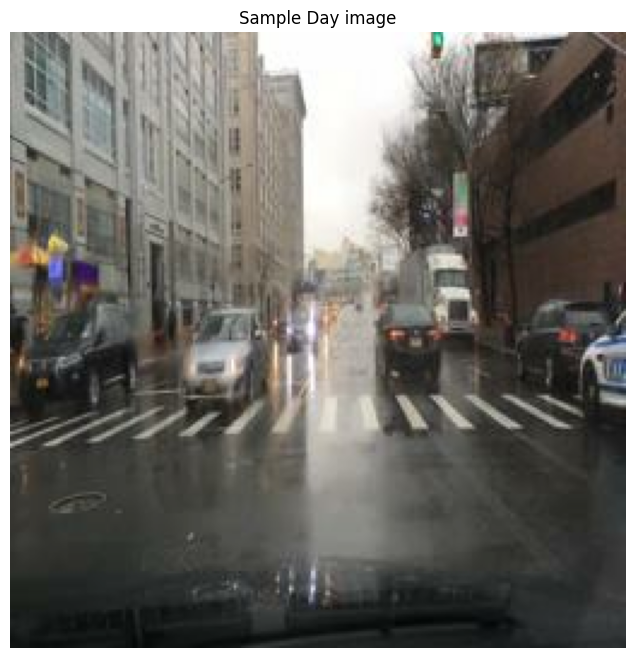

In [6]:
show_sample(Day_Dataset, title='Sample Day image')

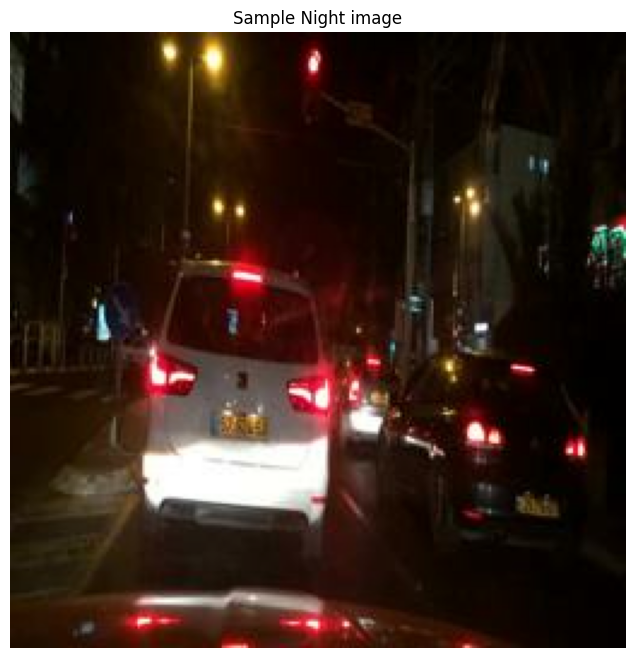

In [7]:
show_sample(Night_Dataset, title='Sample Night image')

In [8]:
conv_init = tf.random_normal_initializer(0., 0.02)
gamma_init = tf.keras.initializers.RandomNormal(0., 0.02)

def downsample(x, filters, name, size=3, strides=2, activation=tf.keras.layers.ReLU()):
    x = tf.keras.layers.SeparableConv2D(filters, size, strides=strides, padding='same',use_bias=False, depthwise_initializer=conv_init,pointwise_initializer=conv_init, name=f"enc_{name}")(x)
    x = tfa.layers.InstanceNormalization(gamma_initializer=gamma_init)(x)
    return activation(x)

def upsample(x, filters, name, size=3, strides=2, activation='relu'):
    x = tf.keras.layers.Conv2DTranspose(filters, size, strides=strides, padding='same',use_bias=False, kernel_initializer=conv_init, name=f"dec_{name}")(x)
    x = tfa.layers.InstanceNormalization(gamma_initializer=gamma_init)(x)
    return tf.keras.layers.Activation(activation)(x)

def residual_block(x, name):
    f = x.shape[-1]
    y = tf.keras.layers.SeparableConv2D(f, 3, padding='same', use_bias=False,depthwise_initializer=conv_init,pointwise_initializer=conv_init, name=f"res_{name}_1")(x)
    y = tf.keras.layers.Activation("relu")(y)
    y = tf.keras.layers.SeparableConv2D(f, 3, padding='same', use_bias=False,depthwise_initializer=conv_init,pointwise_initializer=conv_init, name=f"res_{name}_2")(y)
    return tf.keras.layers.Add()([x, y])

In [9]:
def get_generator(res_blocks=3, base_filters=CFG.BASE_FILTERS):
    inp = tf.keras.layers.Input((CFG.IMG_WIDTH, CFG.IMG_HEIGHT, 3))
    e1 = downsample(inp, base_filters,  "d1", size=7, strides=1)
    e2 = downsample(e1, base_filters*2, "d2")
    e3 = downsample(e2, base_filters*4, "d3")
    e4 = downsample(e3, base_filters*8, "d4")
    x = e4
    for i in range(res_blocks):
        x = residual_block(x, name=f"r{i+1}")
    u1 = upsample(tf.concat([x, e4], -1), base_filters*8, "u1")
    u2 = upsample(tf.concat([u1, e3], -1), base_filters*4, "u2")
    u3 = upsample(tf.concat([u2, e2], -1), base_filters*2, "u3")
    out = tf.keras.layers.Conv2D(3, 7, padding='same', activation='tanh',kernel_initializer=conv_init, name="out")(tf.concat([u3, e1], -1))
    out = tf.cast(out, tf.float16)
    return tf.keras.Model(inp, out)

def PATCH_discriminator(leak=0.2, base_filters=CFG.BASE_FILTERS):
    inp = tf.keras.layers.Input((CFG.IMG_WIDTH, CFG.IMG_HEIGHT, 3))
    act = tf.keras.layers.LeakyReLU(leak)
    x = downsample(inp, base_filters,  "d1", size=4, activation=act)
    x = downsample(x,   base_filters*2, "d2", size=4, activation=act)
    x = downsample(x,  base_filters*4, "d3", size=4, activation=act)
    x = downsample(x,  base_filters*8, "d4", size=4, activation=act)
    out = tf.keras.layers.Conv2D(1, 4, padding='valid', kernel_initializer=conv_init)(x)
    out = tf.cast(out, tf.float16)
    return tf.keras.Model(inp, out)

day2night_gen = get_generator()
night2day_gen = get_generator()
day2night_disc = PATCH_discriminator()
night2day_disc = PATCH_discriminator()

C:\Users\matth\anaconda3\envs\gpu-py310-env\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [28]:
def gen_gan_loss(fake):
    fake32 = tf.cast(fake, tf.float32)
    return bce(tf.ones_like(fake32), fake32)

def disc_loss(real, fake):
    real32 = tf.cast(real, tf.float32)
    fake32 = tf.cast(fake, tf.float32)
    return 0.5 * (bce(tf.ones_like(real32), real32) +
                  bce(tf.zeros_like(fake32), fake32))

def cycle_loss(real, cycled):
    real32 = tf.cast(real, tf.float32)
    cycled32 = tf.cast(cycled, tf.float32)
    return CFG.LAMBDA * tf.reduce_mean(tf.abs(real32 - cycled32))

def identity_loss(real, same):
    real32 = tf.cast(real, tf.float32)
    same32 = tf.cast(same, tf.float32)
    return 0.5 * CFG.LAMBDA * tf.reduce_mean(tf.abs(real32 - same32))

def ssim_loss(a, b):
    a32 = tf.cast((a + 1.0) / 2.0, tf.float32)
    b32 = tf.cast((b + 1.0) / 2.0, tf.float32)
    return 1.0 - tf.reduce_mean(tf.image.ssim(a32, b32, 1.0))

In [29]:
class CycleGAN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.g_d2n = get_generator()
        self.g_n2d = get_generator()
        self.d_d2n = PATCH_discriminator()
        self.d_n2d = PATCH_discriminator()

    def compile(self, lr=CFG.learning_rate):
        self.opt_g_d2n = make_optimizer(lr)
        self.opt_g_n2d = make_optimizer(lr)
        self.opt_d_d2n = make_optimizer(lr)
        self.opt_d_n2d = make_optimizer(lr)
        super().compile()

    @tf.function
    def train_step(self, batch):
        day, night = batch
        with tf.GradientTape() as tape:
            fake_night = self.g_d2n(day, training=True)
            cycled_day = self.g_n2d(fake_night, training=True)
            id_day = self.g_n2d(day, training=True)
            d_fake_night = self.d_d2n(fake_night, training=False)

            g_d2n_loss = (
                generator_gan_loss(tf.cast(d_fake_night, tf.float32))
                + cycle_l1_loss(day, cycled_day)
                + identity_l1_loss(day, id_day)
                + CFG.SSIM_WEIGHT * ssim_loss_fn(fake_night, night)
            )
            scaled = self.opt_g_d2n.get_scaled_loss(g_d2n_loss)

        grads = tape.gradient(scaled, self.g_d2n.trainable_variables)
        grads = self.opt_g_d2n.get_unscaled_gradients(grads)
        grads, _ = tf.clip_by_global_norm(grads, CFG.GRAD_CLIP_NORM)
        self.opt_g_d2n.apply_gradients(zip(grads, self.g_d2n.trainable_variables))
        with tf.GradientTape() as tape:
            fake_day = self.g_n2d(night, training=True)
            cycled_night = self.g_d2n(fake_day, training=True)
            id_night = self.g_d2n(night, training=True)
            d_fake_day = self.d_n2d(fake_day, training=False)

            g_n2d_loss = (
                generator_gan_loss(tf.cast(d_fake_day, tf.float32))
                + cycle_l1_loss(night, cycled_night)
                + identity_l1_loss(night, id_night)
                + CFG.SSIM_WEIGHT * ssim_loss_fn(fake_day, day)
            )

            scaled = self.opt_g_n2d.get_scaled_loss(g_n2d_loss)

        grads = tape.gradient(scaled, self.g_n2d.trainable_variables)
        grads = self.opt_g_n2d.get_unscaled_gradients(grads)
        grads, _ = tf.clip_by_global_norm(grads, CFG.GRAD_CLIP_NORM)
        self.opt_g_n2d.apply_gradients(zip(grads, self.g_n2d.trainable_variables))

        with tf.GradientTape() as tape:
            fake_day_detach = tf.stop_gradient(self.g_n2d(night, training=False))
            d_real_day = self.d_n2d(day, training=True)
            d_fake_day = self.d_n2d(fake_day_detach, training=True)

            d_day_loss = discriminator_loss(tf.cast(d_real_day, tf.float32),
                                            tf.cast(d_fake_day, tf.float32))
            scaled = self.opt_d_n2d.get_scaled_loss(d_day_loss)

        grads = tape.gradient(scaled, self.d_n2d.trainable_variables)
        grads = self.opt_d_n2d.get_unscaled_gradients(grads)
        grads, _ = tf.clip_by_global_norm(grads, CFG.GRAD_CLIP_NORM)
        self.opt_d_n2d.apply_gradients(zip(grads, self.d_n2d.trainable_variables))

        with tf.GradientTape() as tape:
            fake_night_detach = tf.stop_gradient(self.g_d2n(day, training=False))
            d_real_night = self.d_d2n(night, training=True)
            d_fake_night = self.d_d2n(fake_night_detach, training=True)

            d_night_loss = discriminator_loss(tf.cast(d_real_night, tf.float32),
                                              tf.cast(d_fake_night, tf.float32))
            scaled = self.opt_d_d2n.get_scaled_loss(d_night_loss)

        grads = tape.gradient(scaled, self.d_d2n.trainable_variables)
        grads = self.opt_d_d2n.get_unscaled_gradients(grads)
        grads, _ = tf.clip_by_global_norm(grads, CFG.GRAD_CLIP_NORM)
        self.opt_d_d2n.apply_gradients(zip(grads, self.d_d2n.trainable_variables))

        return {
            "gen_D2N_loss": tf.cast(g_d2n_loss, tf.float32),
            "gen_N2D_loss": tf.cast(g_n2d_loss, tf.float32),
            "disc_day_loss": tf.cast(d_day_loss, tf.float32),
            "disc_night_loss": tf.cast(d_night_loss, tf.float32),
        }

In [30]:
gan = CycleGAN()
gan.compile(lr=CFG.learning_rate)

class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=0):
        super().__init__()
        self.patience = patience
        self.best_weights = None

    def on_train_begin(self, logs=None):
        self.wait = 0
        self.stopped_epoch = 0
        self.n2d_loss = np.Inf
        self.d2n_loss = np.Inf

    def on_epoch_end(self, epoch, logs=None):
        n2d_loss = logs.get('gen_N2D_loss')
        d2n_loss = logs.get('gen_D2N_loss')
        if (n2d_loss is None) or (d2n_loss is None):
            return
        if (np.less(n2d_loss, self.n2d_loss) and np.less(d2n_loss, self.d2n_loss)):
            self.d2n_loss = d2n_loss
            self.n2d_loss = n2d_loss
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print("Restoring model weights from the end of the best epoch.")
                if self.best_weights is not None:
                    self.model.set_weights(self.best_weights)

In [31]:
EPOCHS = 50
steps_per_epoch = 300
callbacks = [CustomEarlyStopping(patience=10)]

history = gan.fit(
    Train_Dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks
)

Epoch 1/50
300/300 [==============================] - 195s 552ms/step - gen_D2N_loss: 10.2315 - gen_N2D_loss: 8.3959 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931
Epoch 2/50
300/300 [==============================] - 166s 552ms/step - gen_D2N_loss: 9.7643 - gen_N2D_loss: 7.7352 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931
Epoch 3/50
300/300 [==============================] - 166s 552ms/step - gen_D2N_loss: 9.5528 - gen_N2D_loss: 7.3488 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931
Epoch 4/50
300/300 [==============================] - 165s 551ms/step - gen_D2N_loss: 10.1993 - gen_N2D_loss: 7.4431 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931
Epoch 5/50
300/300 [==============================] - 165s 552ms/step - gen_D2N_loss: 10.9598 - gen_N2D_loss: 7.9611 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931
Epoch 6/50
300/300 [==============================] - 166s 552ms/step - gen_D2N_loss: 11.0222 - gen_N2D_loss: 8.0955 - disc_day_loss: 0.6931 - disc_night_loss: 0.6931


In [32]:
def plot_generator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['gen_D2N_loss']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['gen_D2N_loss'], label='Day→Night Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day→Night Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['gen_N2D_loss'], label='Night→Day Generator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night→Day Generator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_generator_loss(history)

TypeError: 'History' object is not subscriptable

<Figure size 1600x600 with 0 Axes>

In [ ]:
def plot_discriminator_loss(history):
    plt.figure(figsize=(16, 6))
    epochs = range(len(history['disc_day_loss']))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['disc_day_loss'], label='Day Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Day Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['disc_night_loss'], label='Night Discriminator Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Night Discriminator Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_discriminator_loss(history)

In [33]:
def display_generated_day2night(day2night_gen, day_dataset, num_images=5, start_from=1):
    plt.figure(figsize=(20, 10))
    ssim_scores = []

    # Denormalisasi balik [-1,1] → [0,1]
    def denorm(x):
        x = (x * 0.5) + 0.5
        return tf.clip_by_value(x, 0, 1)

    selected = day_dataset.skip(start_from - 1).take(num_images)

    for i, real_day in enumerate(selected):
        if len(real_day.shape) == 4:
            real_day = real_day[0]

        real_batch = tf.expand_dims(real_day, axis=0)

        fake_night = day2night_gen(real_batch, training=False)

        real_show = denorm(real_batch)[0].numpy().astype("float32")
        fake_show = denorm(fake_night)[0].numpy().astype("float32")

        # SSIM
        ssim = tf.image.ssim(real_show, fake_show, max_val=1.0).numpy()
        ssim_scores.append(ssim * 100)

        # Display
        plt.subplot(2, num_images, i + 1)
        plt.imshow(real_show)
        plt.title("Original Day", fontsize=14)
        plt.axis("off")

        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(fake_show)
        plt.title(f"Generated Night\nSSIM: {ssim*100:.2f}%", fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\nRata-rata SSIM: {np.mean(ssim_scores):.2f}%")
    return ssim_scores

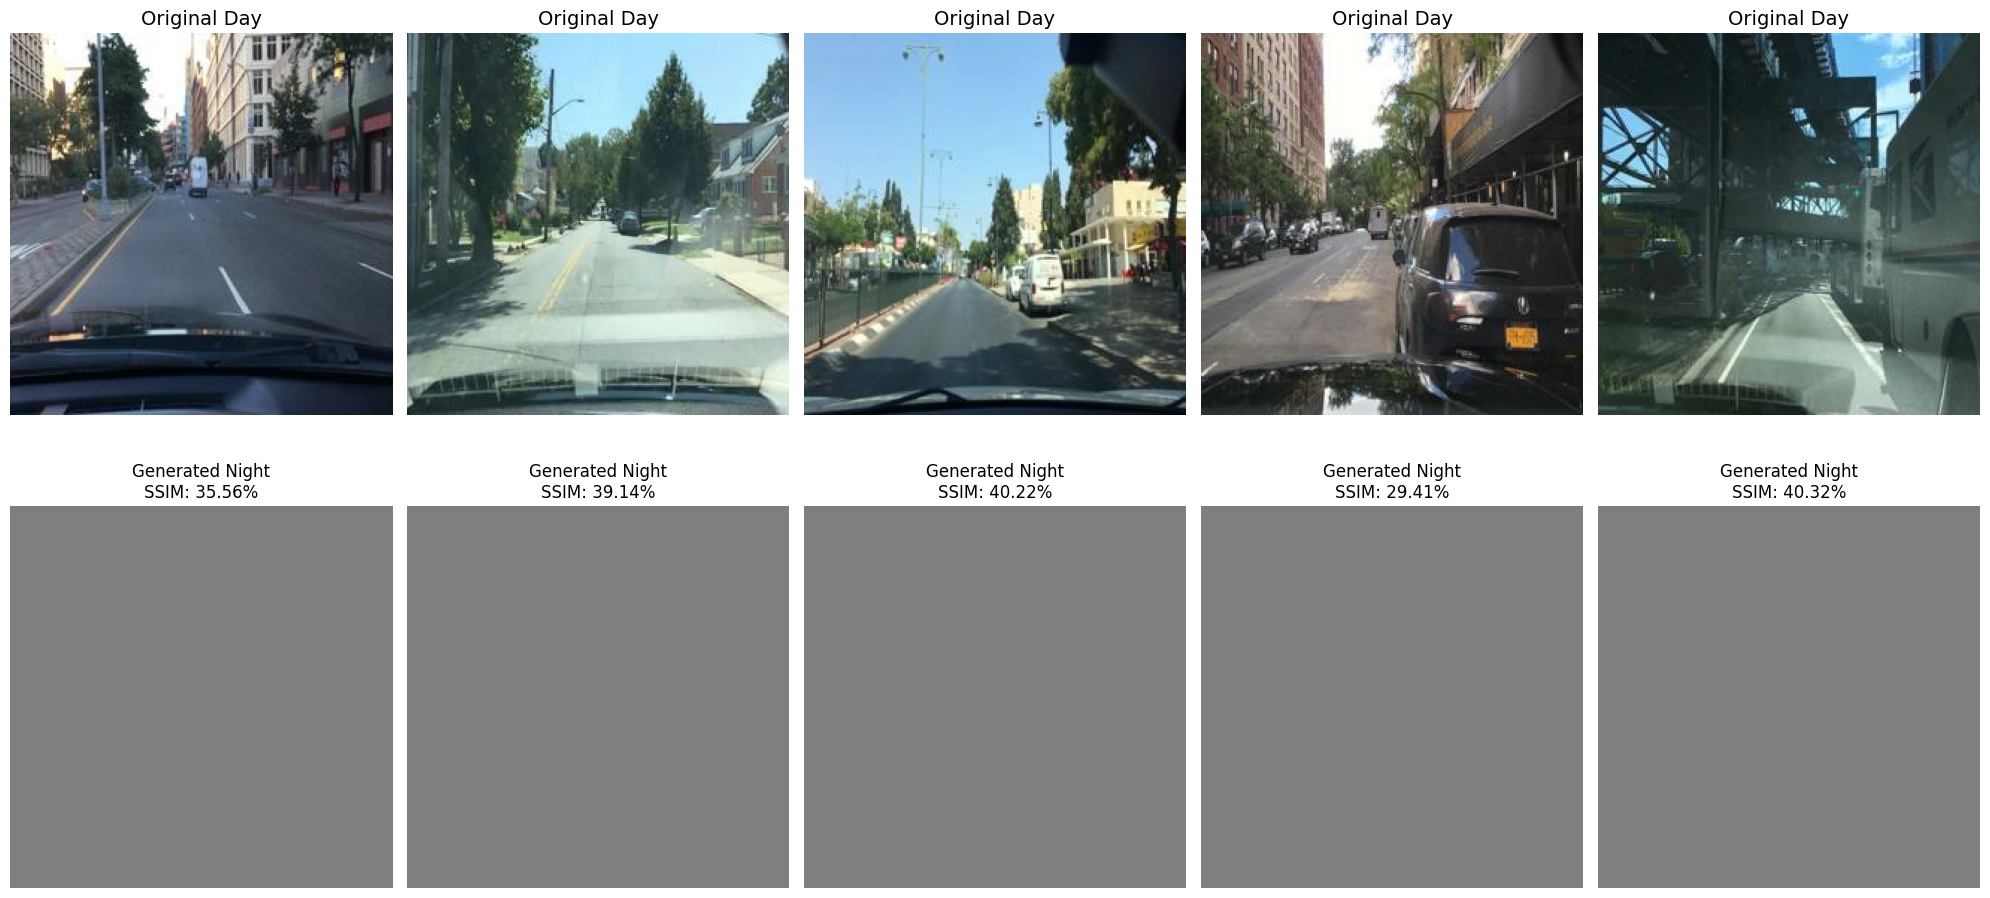


Rata-rata SSIM: 36.93%


[35.55569648742676,
 39.13589417934418,
 40.224266052246094,
 29.410529136657715,
 40.32119810581207]

In [34]:
display_generated_day2night(day2night_gen, Day_eval, num_images=5)

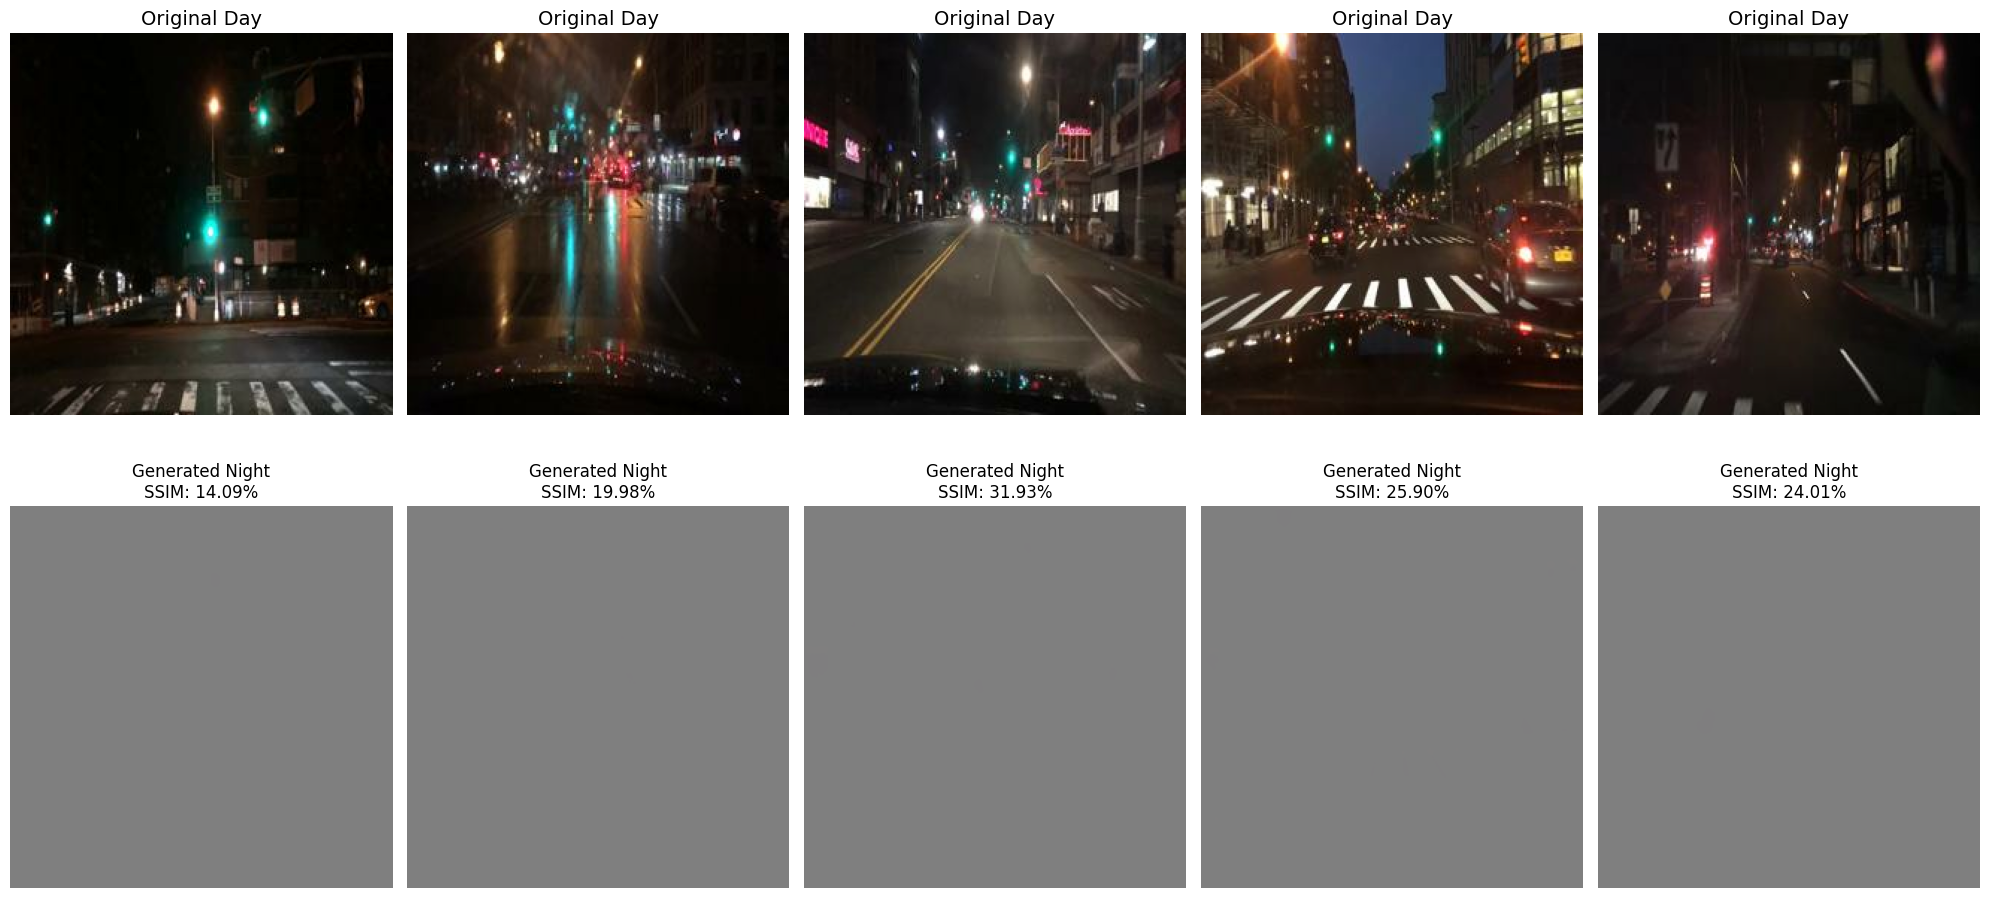


Rata-rata SSIM: 23.18%


[14.08984512090683,
 19.976480305194855,
 31.934157013893127,
 25.90164840221405,
 24.013932049274445]

In [35]:
display_generated_day2night(night2day_gen, Night_eval, num_images=5)